In [2]:
import pandas as pd
import numpy as np
from scipy import stats
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error 
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [3]:
df_c = pd.read_excel("Base de datos experimento combustión ohe_v2.xlsx")
#df_c = df_c.drop("Descriptor - Model Type", axis = 1)
df_c.tail(5)

,Eng Displ,# Cyl,Comb FE (Guide),Comb Unrd Adj FE,Comb Unadj FE,# Gears,Drive Desc,Fuel Usage,Carline Class Desc,Descriptor - Model Type,FE Rating (1-10 rating on Label),Comb CO2 Adjusted,Guzzler?,Gas Guzzler Exempt,Cyl Deact?,Air Aspiration Method Desc
958,2.5,4,35,34.9824,47.0524,6,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,7,254,0,1,N,Naturally Aspirated
959,2.5,4,35,35.0276,47.6525,6,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,7,253,0,1,N,Naturally Aspirated
960,2.4,4,23,23.1620,30.7256,8,4-Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,1,5,380,0,1,N,Turbocharged
961,3.4,6,20,20.1784,26.4074,10,Part-time 4-Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,4,439,0,1,N,Turbocharged
962,2.0,4,24,24.0075,31.8594,8,All Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,0,5,369,0,1,N,Turbocharged


In [4]:
#aplicamos one hot encoding en las variables categóricas y se aplica la estandarización de variables.
df_encoded = pd.get_dummies(df_c, columns=['Cyl Deact?',"Fuel Usage",'Drive Desc', 'Carline Class Desc', 'Air Aspiration Method Desc'])
scaler = MinMaxScaler()
df_scaled = scaler.fit_transform(df_encoded)
df_encoded = pd.DataFrame(df_scaled, columns=df_encoded.columns)
df_encoded.tail(5)

,Eng Displ,# Cyl,Comb FE (Guide),Comb Unrd Adj FE,Comb Unadj FE,# Gears,Descriptor - Model Type,FE Rating (1-10 rating on Label),Comb CO2 Adjusted,Guzzler?,...,Carline Class Desc_Standard Pick-up Trucks 4WD,Carline Class Desc_Standard SUV 2WD,Carline Class Desc_Standard SUV 4WD,Carline Class Desc_Subcompact Cars,Carline Class Desc_Two Seaters,Air Aspiration Method Desc_Naturally Aspirated,Air Aspiration Method Desc_Other,Air Aspiration Method Desc_Supercharged,Air Aspiration Method Desc_Turbocharged,Air Aspiration Method Desc_Turbocharged+Supercharged
958,0.191176,0.076923,0.541667,0.541115,0.517252,0.555556,1.0,0.857143,0.120146,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
959,0.191176,0.076923,0.541667,0.542057,0.525920,0.555556,1.0,0.857143,0.118932,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
960,0.176471,0.076923,0.291667,0.294757,0.281416,0.777778,1.0,0.571429,0.273058,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
961,0.323529,0.230769,0.229167,0.232573,0.219040,1.000000,1.0,0.428571,0.344660,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
962,0.117647,0.076923,0.312500,0.312378,0.297793,0.777778,0.0,0.571429,0.259709,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [5]:
#Dividimos el set en X e Y, y se divide en entrenamiento y prueba
X = df_encoded.drop('Comb FE (Guide)',axis=1)
X = X.drop("Comb Unrd Adj FE",axis=1)
X = X.drop("Comb Unadj FE",axis=1)
X = X.drop("FE Rating (1-10 rating on Label)",axis=1)
X = X.drop("Comb CO2 Adjusted",axis=1)
X = X.drop("Guzzler? ",axis=1)
X = X.drop("Gas Guzzler Exempt",axis=1)
y = df_encoded['Comb FE (Guide)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [6]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) 
print('mean_squared_error : ', mean_squared_error(y_test, predictions)) 
print('mean_absolute_error : ', mean_absolute_error(y_test, predictions)) 
# Valores reales y predicciones
#y_pred = [item for sublist in predictions for item in sublist]
y_pred = predictions
y_real = y_test
#y_pred = [predictions]

# Calcular R²
r2 = r2_score(y_real, y_pred)
print(f"Coeficiente de determinación (R²): {r2}")

mean_squared_error :  0.002606099818771227
mean_absolute_error :  0.038625468569780844
Coeficiente de determinación (R²): 0.8651101686981949


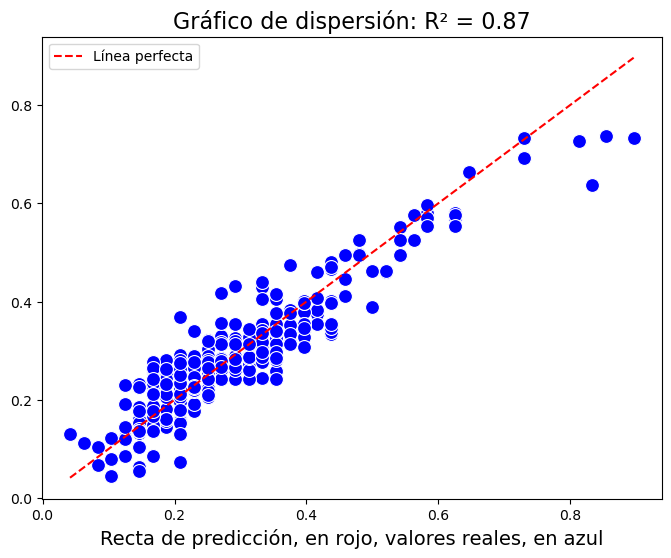

In [7]:
import seaborn as sns

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_real, y=y_pred, color='blue', s=100)

# Dibujar la línea perfecta (y = x)
plt.plot([min(y_real), max(y_real)], [min(y_real), max(y_real)], color='red', linestyle='--', label='Línea perfecta')

# Añadir etiquetas y título
plt.xlabel('Recta de predicción, en rojo, valores reales, en azul', fontsize=14)
#plt.ylabel('Recta de predicción, en rojo, valores reales, en azul', fontsize=14)
plt.title(f'Gráfico de dispersión: R² = {r2:.2f}', fontsize=16)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [8]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=4, shuffle=True, random_state=3)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=kf)
scores

array([0.82771651, 0.85911836, 0.85456425, 0.81624048])

In [9]:
#Repetimos el experimento, pero ahora con el consumo no ajustado

In [10]:
q_hi  = df_encoded["Comb FE (Guide)"].quantile(0.99)

df_filtered = df_encoded[(df_encoded["Comb FE (Guide)"] < q_hi)]
df_filtered

,Eng Displ,# Cyl,Comb FE (Guide),Comb Unrd Adj FE,Comb Unadj FE,# Gears,Descriptor - Model Type,FE Rating (1-10 rating on Label),Comb CO2 Adjusted,Guzzler?,...,Carline Class Desc_Standard Pick-up Trucks 4WD,Carline Class Desc_Standard SUV 2WD,Carline Class Desc_Standard SUV 4WD,Carline Class Desc_Subcompact Cars,Carline Class Desc_Two Seaters,Air Aspiration Method Desc_Naturally Aspirated,Air Aspiration Method Desc_Other,Air Aspiration Method Desc_Supercharged,Air Aspiration Method Desc_Turbocharged,Air Aspiration Method Desc_Turbocharged+Supercharged
0,0.588235,0.692308,0.104167,0.112696,0.102832,0.555556,0.0,0.142857,0.563107,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,0.264706,0.230769,0.354167,0.351903,0.336662,0.777778,0.0,0.571429,0.222087,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,0.117647,0.076923,0.395833,0.396183,0.383055,0.777778,0.0,0.714286,0.190534,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
3,1.000000,1.000000,0.000000,0.000000,0.000000,0.666667,0.0,0.000000,1.000000,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
4,0.735294,0.384615,0.208333,0.209535,0.183677,0.777778,0.0,0.428571,0.384709,0.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
958,0.191176,0.076923,0.541667,0.541115,0.517252,0.555556,1.0,0.857143,0.120146,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
959,0.191176,0.076923,0.541667,0.542057,0.525920,0.555556,1.0,0.857143,0.118932,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
960,0.176471,0.076923,0.291667,0.294757,0.281416,0.777778,1.0,0.571429,0.273058,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
961,0.323529,0.230769,0.229167,0.232573,0.219040,1.000000,1.0,0.428571,0.344660,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [11]:
y = df_encoded['Comb Unadj FE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [12]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) 
print('mean_squared_error : ', mean_squared_error(y_test, predictions)) 
print('mean_absolute_error : ', mean_absolute_error(y_test, predictions)) 
# Valores reales y predicciones
#y_pred = [item for sublist in predictions for item in sublist]
y_pred = predictions
y_real = y_test
#y_pred = [predictions]

# Calcular R²
r2 = r2_score(y_real, y_pred)
print(f"Coeficiente de determinación (R²): {r2}")

mean_squared_error :  0.002749506733592966
mean_absolute_error :  0.03955743043534827
Coeficiente de determinación (R²): 0.8608245723813177


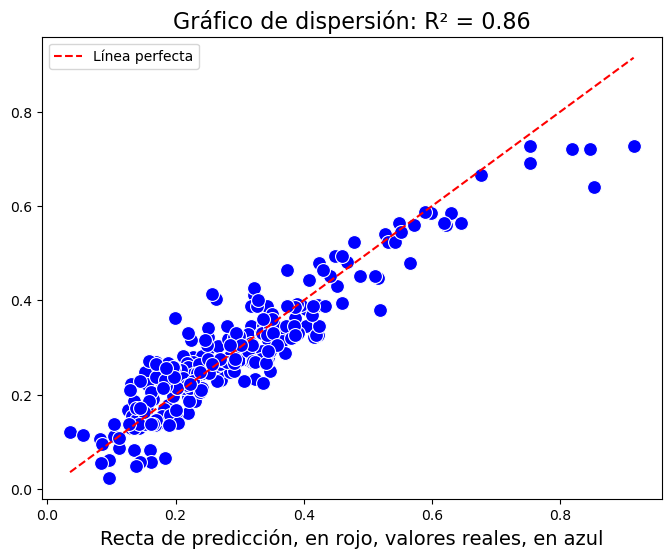

In [13]:
import seaborn as sns

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_real, y=y_pred, color='blue', s=100)

# Dibujar la línea perfecta (y = x)
plt.plot([min(y_real), max(y_real)], [min(y_real), max(y_real)], color='red', linestyle='--', label='Línea perfecta')

# Añadir etiquetas y título
plt.xlabel('Recta de predicción, en rojo, valores reales, en azul', fontsize=14)
plt.title(f'Gráfico de dispersión: R² = {r2:.2f}', fontsize=16)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [14]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
kf = KFold(n_splits=4, shuffle=True, random_state=3)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=kf)
scores

array([0.82651818, 0.86142666, 0.85050974, 0.80886384])

#Otro experimento que se puede realizar es uno en el que se aumente el umbral de variables correlacionadas con el consumo a 0,5.

In [15]:
df_c = pd.read_excel("Base de datos experimento combustión ohe_v2.xlsx")
#df_c = df_c.drop("Descriptor - Model Type", axis = 1)
df_c.tail(5)

,Eng Displ,# Cyl,Comb FE (Guide),Comb Unrd Adj FE,Comb Unadj FE,# Gears,Drive Desc,Fuel Usage,Carline Class Desc,Descriptor - Model Type,FE Rating (1-10 rating on Label),Comb CO2 Adjusted,Guzzler?,Gas Guzzler Exempt,Cyl Deact?,Air Aspiration Method Desc
958,2.5,4,35,34.9824,47.0524,6,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,7,254,0,1,N,Naturally Aspirated
959,2.5,4,35,35.0276,47.6525,6,All Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,7,253,0,1,N,Naturally Aspirated
960,2.4,4,23,23.1620,30.7256,8,4-Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,1,5,380,0,1,N,Turbocharged
961,3.4,6,20,20.1784,26.4074,10,Part-time 4-Wheel Drive,Gasoline (Regular Unleaded Recommended),Standard SUV 4WD,1,4,439,0,1,N,Turbocharged
962,2.0,4,24,24.0075,31.8594,8,All Wheel Drive,Gasoline (Premium Unleaded Required),Standard SUV 4WD,0,5,369,0,1,N,Turbocharged


In [16]:
#Dividimos el set en X e Y, y se divide en entrenamiento y prueba
X = df_c.drop('Comb FE (Guide)',axis=1)
X = X.drop("Comb Unrd Adj FE",axis=1)
X = X.drop("Comb Unadj FE",axis=1)
X = X.drop("FE Rating (1-10 rating on Label)",axis=1)
X = X.drop("Comb CO2 Adjusted",axis=1)
X = X.drop("Guzzler? ",axis=1)
X = X.drop("Gas Guzzler Exempt",axis=1)
X = X.drop("Drive Desc", axis = 1)
X = X.drop("Cyl Deact?", axis = 1)
X = X.drop("Fuel Usage", axis = 1)
X = X.drop("Air Aspiration Method Desc", axis = 1)
X = X.drop("Carline Class Desc", axis = 1)
y = df_c['Comb FE (Guide)']

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [18]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) 
print('mean_squared_error : ', mean_squared_error(y_test, predictions)) 
print('mean_absolute_error : ', mean_absolute_error(y_test, predictions)) 
# Valores reales y predicciones
#y_pred = [item for sublist in predictions for item in sublist]
y_pred = predictions
y_real = y_test
#y_pred = [predictions]

# Calcular R²
r2 = r2_score(y_real, y_pred)
print(f"Coeficiente de determinación (R²): {r2}")
kf = KFold(n_splits=4, shuffle=True, random_state=3)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=kf)
scores

mean_squared_error :  12.421785524025788
mean_absolute_error :  2.8026979332268653
Coeficiente de determinación (R²): 0.7209450586679884


array([0.69487124, 0.71529807, 0.69909079, 0.69250295])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


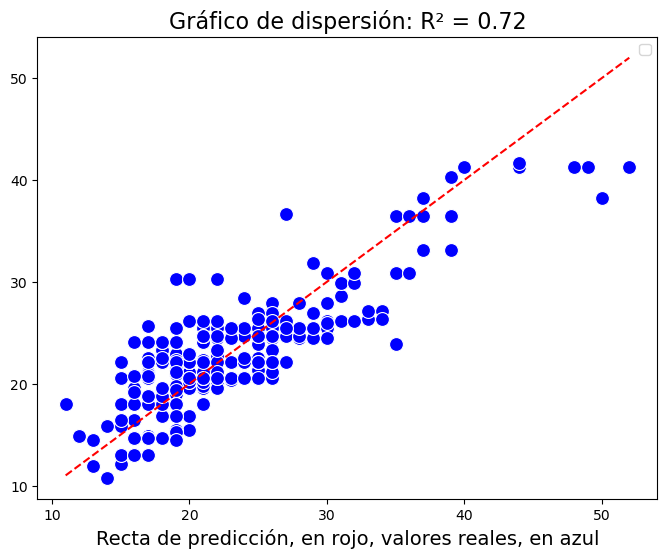

In [19]:
import seaborn as sns

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_real, y=y_pred, color='blue', s=100)

# Dibujar la línea perfecta (y = x)
plt.plot([min(y_real), max(y_real)], [min(y_real), max(y_real)], color='red', linestyle='--')

# Añadir etiquetas y título
plt.xlabel('Recta de predicción, en rojo, valores reales, en azul', fontsize=14)
plt.title(f'Gráfico de dispersión: R² = {r2:.2f}', fontsize=16)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()

In [20]:
y = df_c['Comb Unadj FE']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=2)

In [97]:
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test) 
print('mean_squared_error : ', mean_squared_error(y_test, predictions)) 
print('mean_absolute_error : ', mean_absolute_error(y_test, predictions)) 
# Valores reales y predicciones
#y_pred = [item for sublist in predictions for item in sublist]
y_pred = predictions
y_real = y_test
#y_pred = [predictions]

# Calcular R²
r2 = r2_score(y_real, y_pred)
print(f"Coeficiente de determinación (R²): {r2}")

kf = KFold(n_splits=4, shuffle=True, random_state=3)
model = LinearRegression()
model.fit(X_train, y_train)
predictions = model.predict(X_test)
scores = cross_val_score(model, X, y, cv=kf)
scores

mean_squared_error :  25.474662099133045
mean_absolute_error :  4.006021819994504
Coeficiente de determinación (R²): 0.7309479358885951


array([0.70005717, 0.72354158, 0.70810119, 0.70571902])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


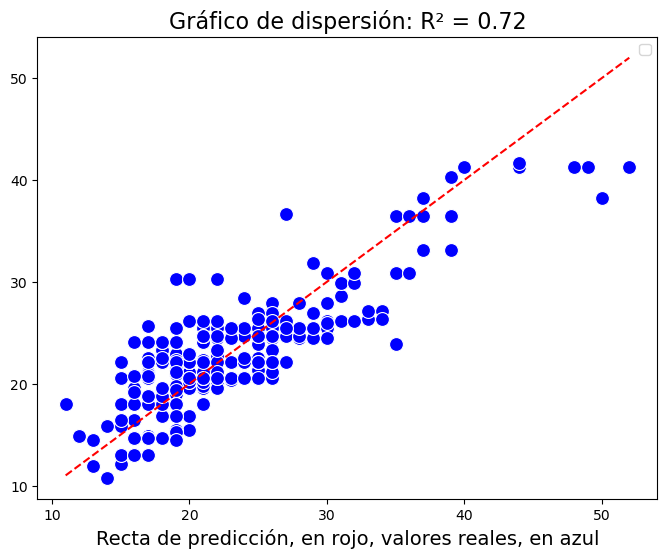

In [22]:
import seaborn as sns

# Crear el gráfico de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_real, y=y_pred, color='blue', s=100)

# Dibujar la línea perfecta (y = x)
plt.plot([min(y_real), max(y_real)], [min(y_real), max(y_real)], color='red', linestyle='--', label='')

# Añadir etiquetas y título
plt.xlabel('Recta de predicción, en rojo, valores reales, en azul', fontsize=14)
plt.title(f'Gráfico de dispersión: R² = {r2:.2f}', fontsize=16)

# Añadir leyenda
plt.legend()

# Mostrar el gráfico
plt.show()